<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_2_(Exercise_2_3)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
#  Data Loading

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.CIFAR10(root='./data', train=True,
                               download=True, transform=transform)
train_data = Subset(train_data, range(10000))
train_loader = DataLoader(train_data, batch_size=64,
                          shuffle=True, num_workers=0)

Using: cpu


In [9]:
# Building Blocks

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
        )
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        h = self.block(x)
        return self.pool(h), h   # pooled output AND pre-pool features


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, use_skip=True):
        super().__init__()
        self.use_skip = use_skip
        self.up = nn.ConvTranspose2d(in_ch, in_ch, kernel_size=2, stride=2)

        # If using skip: input to conv is in_ch + skip_ch
        # If not:        input to conv is in_ch only
        conv_in = in_ch + skip_ch if use_skip else in_ch

        self.block = nn.Sequential(
            nn.Conv2d(conv_in, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
        )

    def forward(self, x, skip=None):
        x = self.up(x)
        if self.use_skip and skip is not None:
            x = torch.cat([x, skip], dim=1)   # concatenate along channel dim
        return self.block(x)

In [10]:
# Full Encoder-Decoder

class UNet(nn.Module):
    def __init__(self, use_skip=True):
        super().__init__()
        self.use_skip = use_skip

        # Encoder
        self.down1 = DownBlock(3, 32)     # 32×32 → 16×16
        self.down2 = DownBlock(32, 64)    # 16×16 → 8×8
        self.down3 = DownBlock(64, 128)   # 8×8   → 4×4

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.GroupNorm(8, 256),
            nn.SiLU(),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.GroupNorm(8, 128),
            nn.SiLU(),
        )

        # Decoder
        self.up1 = UpBlock(128, 128, 64,  use_skip=use_skip)
        self.up2 = UpBlock(64,  64,  32,  use_skip=use_skip)
        self.up3 = UpBlock(32,  32,  16,  use_skip=use_skip)

        # Output head
        self.out_conv = nn.Conv2d(16, 3, 1)

    def forward(self, x):
        # Encode
        x1, skip1 = self.down1(x)
        x2, skip2 = self.down2(x1)
        x3, skip3 = self.down3(x2)

        # Bottleneck
        x = self.bottleneck(x3)

        # Decode — pass skips only if use_skip=True
        x = self.up1(x, skip3 if self.use_skip else None)
        x = self.up2(x, skip2 if self.use_skip else None)
        x = self.up3(x, skip1 if self.use_skip else None)

        return self.out_conv(x)

In [11]:
# Training Loop

def train(model, loader, epochs=10, label=''):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.L1Loss()

    for epoch in range(epochs):
        total_loss = 0
        for imgs, _ in loader:
            imgs = imgs.to(device)

            # Add noise — this is the reconstruction task
            noise = torch.randn_like(imgs) * 0.5
            noisy = (imgs + noise).clamp(-1, 1)

            pred = model(noisy)
            loss = criterion(pred, imgs)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg = total_loss / len(loader)
        print(f"[{label}] Epoch {epoch+1}/10 — Loss: {avg:.4f}")

    return model

print("Training WITH skip connections...")
model_skip    = train(UNet(use_skip=True),  train_loader, epochs=3, label='With Skip')

print("\nTraining WITHOUT skip connections...")
model_noskip  = train(UNet(use_skip=False), train_loader, epochs=3, label='No Skip')

Training WITH skip connections...
[With Skip] Epoch 1/10 — Loss: 0.1649
[With Skip] Epoch 2/10 — Loss: 0.1215
[With Skip] Epoch 3/10 — Loss: 0.1141

Training WITHOUT skip connections...
[No Skip] Epoch 1/10 — Loss: 0.3084
[No Skip] Epoch 2/10 — Loss: 0.2141
[No Skip] Epoch 3/10 — Loss: 0.1915


In [12]:
# Hook Into Gradients

def get_gradient_magnitudes(model, loader):
    model.eval()
    grad_magnitudes = {}

    # Register a hook on every Conv2d layer
    hooks = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            def make_hook(n):
                def hook(grad):
                    grad_magnitudes[n] = grad.abs().mean().item()
                return hook
            hooks.append(
                module.weight.register_hook(make_hook(name))
            )

    # One forward + backward pass on a single batch
    imgs, _ = next(iter(loader))
    imgs = imgs.to(device)
    noise = torch.randn_like(imgs) * 0.5
    noisy = (imgs + noise).clamp(-1, 1)

    model.zero_grad()
    pred = model(noisy)
    loss = nn.L1Loss()(pred, imgs)
    loss.backward()

    # Remove hooks
    for h in hooks:
        h.remove()

    return grad_magnitudes

grads_skip   = get_gradient_magnitudes(model_skip,   train_loader)
grads_noskip = get_gradient_magnitudes(model_noskip, train_loader)

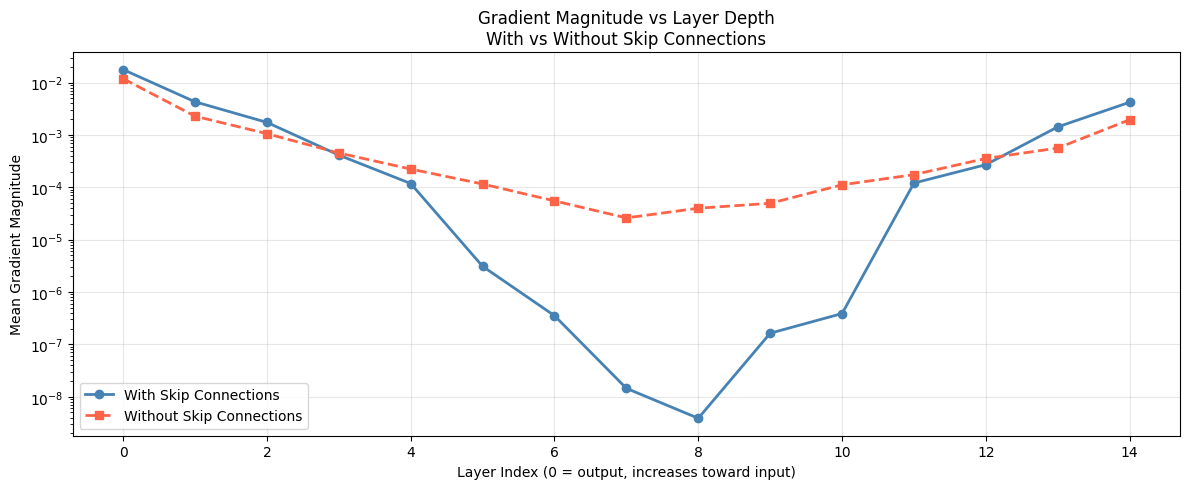

In [13]:
# Plot Gradient Magnitude vs Layer Depth

def plot_gradients(grads_skip, grads_noskip):
    layers_skip   = list(grads_skip.keys())
    layers_noskip = list(grads_noskip.keys())

    vals_skip   = [grads_skip[l]   for l in layers_skip]
    vals_noskip = [grads_noskip[l] for l in layers_noskip]

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(range(len(vals_skip)),   vals_skip,
            marker='o', label='With Skip Connections',
            color='steelblue', linewidth=2)

    ax.plot(range(len(vals_noskip)), vals_noskip,
            marker='s', label='Without Skip Connections',
            color='tomato',    linewidth=2, linestyle='--')

    ax.set_xlabel('Layer Index (0 = output, increases toward input)')
    ax.set_ylabel('Mean Gradient Magnitude')
    ax.set_title('Gradient Magnitude vs Layer Depth\nWith vs Without Skip Connections')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')    # log scale — gradients span orders of magnitude

    plt.tight_layout()
    plt.savefig('exercise_2_3.png', dpi=150)
    plt.show()

plot_gradients(grads_skip, grads_noskip)

# The Real Story The Plot Tells:
#### WITHOUT skip (red — flat line):
Gradient flows through every layer equally
but at a uniformly low level (~10⁻⁴ everywhere)
Early layers get weak but consistent gradients
Nothing is starved, nothing is well-fed
→ Mediocre learning everywhere

### WITH skip (blue — V-shape):
Gradient flows through skip connections directly
Early encoder layers → well-fed (right side of V)
Bottleneck → starved (bottom of V)
Late decoder layers → well-fed (left side of V)
→ Strong learning where it matters,
   bottleneck learns to be a compact bridge only

# Interpretation

#### `The gradient plot reveals that skip connections produce a V-shaped gradient profile rather than a uniformly flat one — the bottleneck receives near-zero gradients (~3×10⁻⁹) while early encoder and late decoder layers receive comparatively strong gradients via the direct skip paths. This happens because the skip connections provide a lower-resistance backward path that gradient naturally favours over the longer bottleneck route, effectively dividing the network into two learning regimes: skip-connected layers that learn fine spatial reconstruction and a bottleneck that learns only compact global representations. Without skip connections the gradient is more uniform across depths but stays at a consistently low level (~10⁻⁴) everywhere, meaning no layer receives strong enough signal to specialise. In LDAE's U-Net this division is architecturally intentional — skip connections handle the fine anatomical detail that must survive the 170× compression, while the bottleneck is left to encode only the global structure that the diffusion process operates on.`


```
CIFAR-10 image (clean)
  ↓
Add random Gaussian noise → noisy image
(this is the reconstruction task — input is noisy, target is clean)
  ↓
─────────────────── ENCODER ───────────────────
  ↓
DownBlock 1 → extracts low-level features (edges, textures)
              saves skip1, then halves spatial size
  ↓
DownBlock 2 → extracts mid-level features
              saves skip2, then halves spatial size
  ↓
DownBlock 3 → extracts high-level features
              saves skip3, then halves spatial size
  ↓
─────────────────── BOTTLENECK ─────────────────
  ↓
Most compressed representation
(fine spatial detail is mostly lost here)
  ↓
─────────────────── DECODER ────────────────────
  ↓
UpBlock 1 → upsample back up
            WITH skip:    concat skip3 → has fine detail restored
            WITHOUT skip: just upsample → fine detail permanently lost
  ↓
UpBlock 2 → upsample back up
            WITH skip:    concat skip2
            WITHOUT skip: just upsample
  ↓
UpBlock 3 → upsample back up
            WITH skip:    concat skip1
            WITHOUT skip: just upsample
  ↓
Output Conv → reconstructed clean image
  ↓
L1 Loss vs original clean image
  ↓
─────────────── BACKWARD PASS ──────────────────
  ↓
Gradients flow backward through every layer
  ↓
PyTorch hooks intercept gradient at each Conv2d
and record its magnitude
  ↓
─────────────── GRADIENT PLOT ──────────────────
  ↓
WITHOUT skip: gradient magnitude drops exponentially
              toward zero at early encoder layers
              → early layers learn nothing
  ↓
WITH skip:    gradient magnitude stays relatively flat
              across all depths — direct backward path
              through skip connections bypasses bottleneck
  ↓
Log-scale plot reveals the difference clearly
```




# How the entire module connects
```
2.2 — Sinusoidal Embedding
      "how do we represent t as a vector"
              ↓ feeds into
2.1 — AdaGN ResBlock
      "how does t condition the network at each layer"
              ↓ stacked inside
2.3 — U-Net with Skip Connections
      "how do gradients survive across the full depth
       of a network made of many 2.1 blocks"
```

